# LINEAR REGRESSION WITH GRADIENT DESCENT

## Case: BFSI – Credit Score → Interest Rate

## Objective

Apply Linear Regression with Gradient Descent on real-world inspired problems. Most problems involve 
one predictor variable (single regression) so you understand the core mechanics. A few problems touch 
upon two predictors to show how models scale.

## Problem statement

### Step 1: Load library

In [1]:
# ============================================================
# ASSIGNMENT 3: LINEAR REGRESSION WITH GRADIENT DESCENT
# Case: BFSI – Credit Score → Interest Rate
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)

### Step 2: DATASET

In [2]:
credit_scores  = np.random.randint(300, 901, size=500)
interest_rates = 20 - ((credit_scores - 300) / 600) * 17 + np.random.normal(0, 1, 500)
interest_rates = np.clip(interest_rates, 3, 20)
df = pd.DataFrame({'Credit_Score': credit_scores,
                   'Interest_Rate': np.round(interest_rates, 2)})
print("Dataset:\n", df.head(10).to_string(index=False))
print("\nStats:\n", df.describe().round(2))
print(f"\nCorrelation: {df['Credit_Score'].corr(df['Interest_Rate']):.4f}")

Dataset:
  Credit_Score  Interest_Rate
          402          18.44
          735           6.72
          570          10.01
          406          16.65
          371          16.97
          320          20.00
          421          15.85
          766           4.92
          514          13.36
          630           9.16

Stats:
        Credit_Score  Interest_Rate
count        500.00         500.00
mean         592.18          11.76
std          172.05           4.94
min          301.00           3.00
25%          443.00           7.81
50%          582.00          12.04
75%          747.50          16.00
max          900.00          20.00

Correlation: -0.9778


### Step 3: EDA 

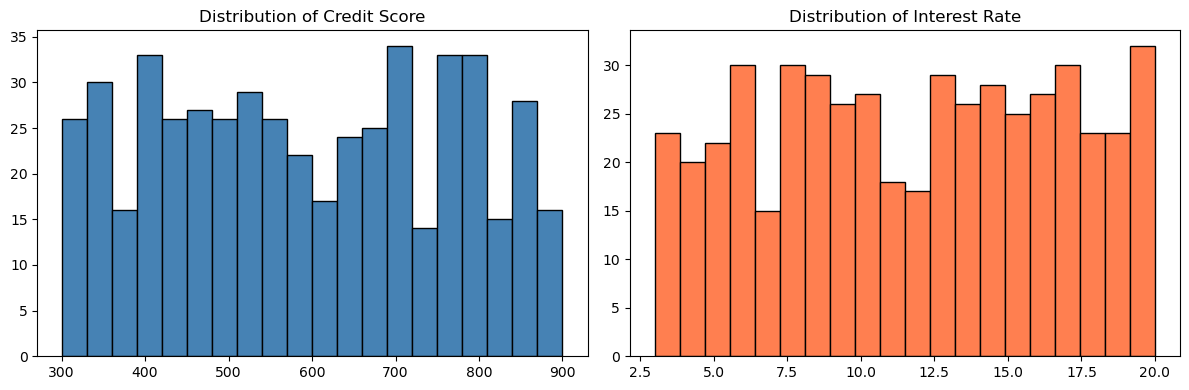

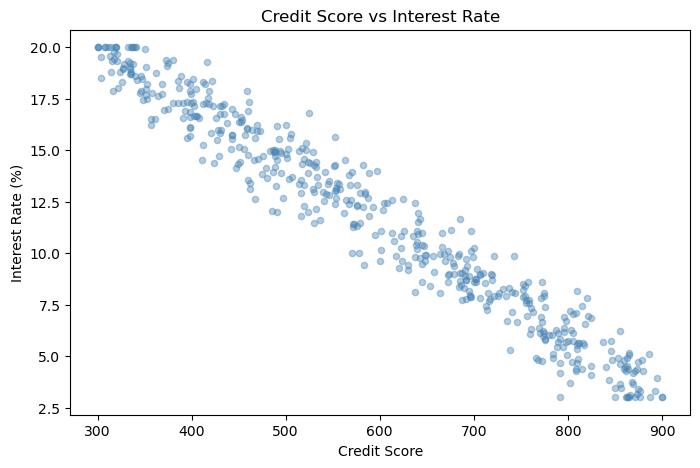

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Credit_Score'],  bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Credit Score')
axes[1].hist(df['Interest_Rate'], bins=20, color='coral',     edgecolor='black')
axes[1].set_title('Distribution of Interest Rate')
plt.tight_layout(); plt.savefig('eda_histograms.png', dpi=150); plt.show()

plt.figure(figsize=(8,5))
plt.scatter(df['Credit_Score'], df['Interest_Rate'], alpha=0.4, color='steelblue', s=20)
plt.title('Credit Score vs Interest Rate'); plt.xlabel('Credit Score')
plt.ylabel('Interest Rate (%)'); plt.savefig('eda_scatter.png', dpi=150); plt.show()


### Step 4: GRADIENT DESCENT 

In [4]:
X = df['Credit_Score'].values.astype(float)
Y = df['Interest_Rate'].values.astype(float)
X_norm = (X - X.mean()) / X.std()

lr, epochs, m, b, n = 0.01, 1000, 0.0, 0.0, len(X_norm)
loss_history = []

for epoch in range(epochs):
    Y_pred = m * X_norm + b
    loss   = (1/n) * np.sum((Y_pred - Y) ** 2)
    loss_history.append(loss)
    dm = (2/n) * np.sum((Y_pred - Y) * X_norm)
    db = (2/n) * np.sum(Y_pred - Y)
    m -= lr * dm; b -= lr * db
    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss:.4f} | m: {m:.4f} | b: {b:.4f}")

m_orig = m / X.std()
b_orig = b - m * X.mean() / X.std()
print(f"\nEquation: Interest Rate = {m_orig:.6f} × Credit_Score + {b_orig:.4f}")


Epoch    0 | Loss: 162.5642 | m: -0.0964 | b: 0.2352
Epoch  100 | Loss: 3.9085 | m: -4.1951 | b: 10.2297
Epoch  200 | Loss: 1.1180 | m: -4.7386 | b: 11.5552
Epoch  300 | Loss: 1.0690 | m: -4.8107 | b: 11.7310
Epoch  400 | Loss: 1.0681 | m: -4.8203 | b: 11.7543
Epoch  500 | Loss: 1.0681 | m: -4.8216 | b: 11.7574
Epoch  600 | Loss: 1.0681 | m: -4.8217 | b: 11.7578
Epoch  700 | Loss: 1.0681 | m: -4.8218 | b: 11.7578
Epoch  800 | Loss: 1.0681 | m: -4.8218 | b: 11.7578
Epoch  900 | Loss: 1.0681 | m: -4.8218 | b: 11.7578

Equation: Interest Rate = -0.028053 × Credit_Score + 28.3702


### Step 5: EVALUATION

In [5]:
Y_pred_norm = m * X_norm + b
mae  = mean_absolute_error(Y, Y_pred_norm)
mse  = mean_squared_error(Y, Y_pred_norm)
rmse = np.sqrt(mse)
r2   = r2_score(Y, Y_pred_norm)
print(f"\nMAE={mae:.4f} | MSE={mse:.4f} | RMSE={rmse:.4f} | R²={r2:.4f}")

for score in [800, 400]:
    pred = np.clip(m * (score - X.mean())/X.std() + b, 3, 20)
    print(f"Credit Score {score} → Interest Rate: {pred:.2f}%")


MAE=0.8187 | MSE=1.0681 | RMSE=1.0335 | R²=0.9561
Credit Score 800 → Interest Rate: 5.93%
Credit Score 400 → Interest Rate: 17.15%


### Step 6: CHARTS

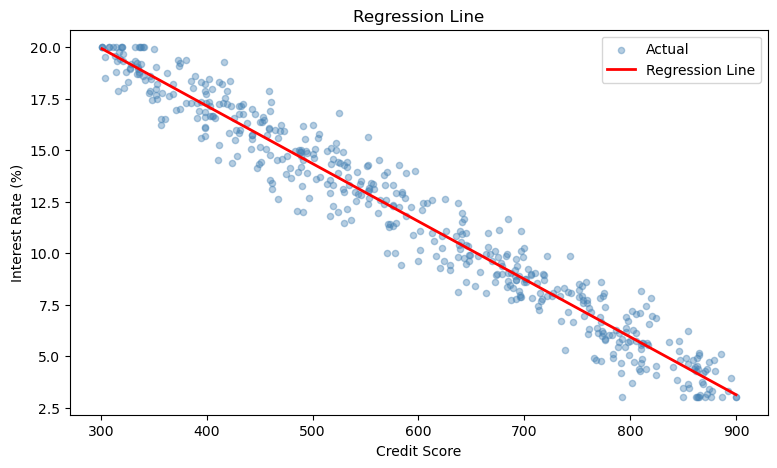

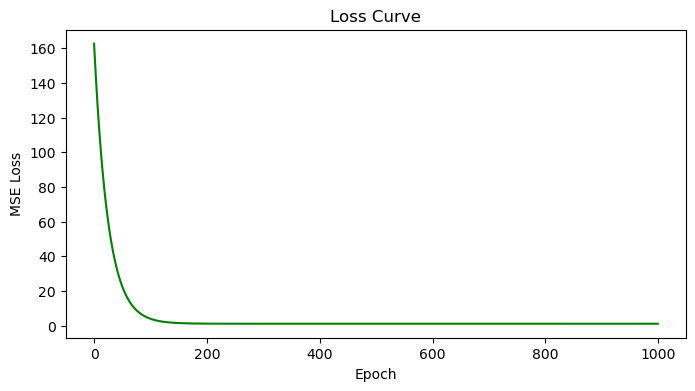

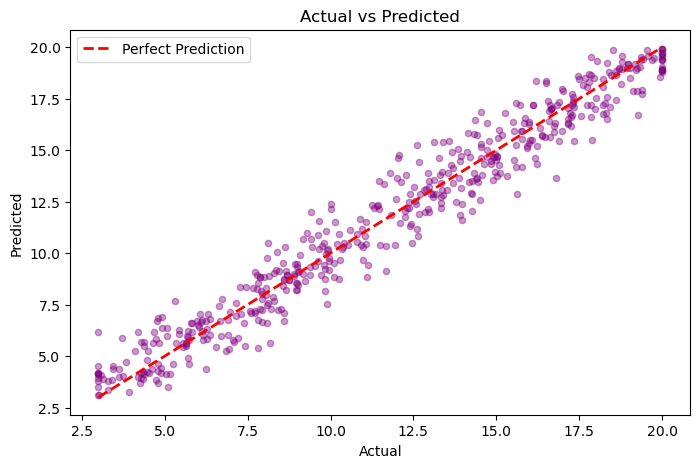


Done! All charts saved.


In [6]:
plt.figure(figsize=(9,5))
plt.scatter(X, Y, alpha=0.4, color='steelblue', s=20, label='Actual')
X_line = np.linspace(X.min(), X.max(), 300)
plt.plot(X_line, m*(X_line-X.mean())/X.std()+b, color='red', lw=2, label='Regression Line')
plt.title('Regression Line'); plt.xlabel('Credit Score'); plt.ylabel('Interest Rate (%)')
plt.legend(); plt.savefig('regression_line.png', dpi=150); plt.show()

plt.figure(figsize=(8,4))
plt.plot(loss_history, color='green')
plt.title('Loss Curve'); plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.savefig('loss_curve.png', dpi=150); plt.show()

plt.figure(figsize=(8,5))
plt.scatter(Y, Y_pred_norm, alpha=0.4, color='purple', s=20)
plt.plot([Y.min(),Y.max()],[Y.min(),Y.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Actual vs Predicted'); plt.xlabel('Actual'); plt.ylabel('Predicted')
plt.legend(); plt.savefig('actual_vs_predicted.png', dpi=150); plt.show()

print("\nDone! All charts saved.")